In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error, r2_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported!')

✅ Libraries imported!


In [2]:
df = pd.read_csv('../data/processed_data.csv')
print(f'✅ Data loaded: {df.shape[0]} rows')
print(df[['district', 'date', 'total_disease_cases']].head(5))

✅ Data loaded: 1008 rows
  district        date  total_disease_cases
0  Chennai  2018-01-01                  104
1  Chennai  2018-02-01                  139
2  Chennai  2018-03-01                   82
3  Chennai  2018-04-01                   95
4  Chennai  2018-05-01                   59


In [3]:
feature_cols = [
    'rainfall_mm',
    'temperature_celsius',
    'pH',
    'turbidity_NTU',
    'coliform_count_per100ml',
    'dissolved_oxygen_mg_L',
    'total_dissolved_solids_mg_L',
    'month',
    'district_encoded',
    'season_encoded',
    'cases_last_month',
    'cases_2_months_ago',
    'rainfall_last_month'
]

target_col = 'total_disease_cases'

X = df[feature_cols]
y = df[target_col]

print(f'✅ Features: {len(feature_cols)}')
print(f'🎯 Target: {target_col}')
print(f'\nTarget statistics:')
print(y.describe().round(1))

✅ Features: 13
🎯 Target: total_disease_cases

Target statistics:
count    1008.0
mean      120.1
std        36.2
min        34.0
25%        95.0
50%       115.0
75%       140.0
max       247.0
Name: total_disease_cases, dtype: float64


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print('✅ Train-Test Split Done!')
print(f'📊 Training set: {X_train.shape[0]} rows')
print(f'📊 Testing set:  {X_test.shape[0]} rows')

✅ Train-Test Split Done!
📊 Training set: 806 rows
📊 Testing set:  202 rows


In [5]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print('📊 LINEAR REGRESSION RESULTS')
print(f'MAE:  {lr_mae:.2f} cases')
print(f'RMSE: {lr_rmse:.2f} cases')
print(f'R²:   {lr_r2:.3f}')

📊 LINEAR REGRESSION RESULTS
MAE:  13.49 cases
RMSE: 16.91 cases
R²:   0.792


In [6]:
rf_reg_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_reg_model.fit(X_train, y_train)
rf_reg_pred = rf_reg_model.predict(X_test)

rf_reg_mae = mean_absolute_error(y_test, rf_reg_pred)
rf_reg_rmse = np.sqrt(mean_squared_error(y_test, rf_reg_pred))
rf_reg_r2 = r2_score(y_test, rf_reg_pred)

print('📊 RANDOM FOREST REGRESSOR RESULTS')
print(f'MAE:  {rf_reg_mae:.2f} cases')
print(f'RMSE: {rf_reg_rmse:.2f} cases')
print(f'R²:   {rf_reg_r2:.3f}')

📊 RANDOM FOREST REGRESSOR RESULTS
MAE:  14.00 cases
RMSE: 17.77 cases
R²:   0.770


In [7]:
reg_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [lr_mae, rf_reg_mae],
    'RMSE': [lr_rmse, rf_reg_rmse],
    'R2_Score': [lr_r2, rf_reg_r2]
})

print('📊 REGRESSION MODEL COMPARISON')
print(reg_comparison.round(3).to_string(index=False))

best_reg_name = reg_comparison.loc[
    reg_comparison['R2_Score'].idxmax(), 'Model']
print(f'\n🏆 Best Regression Model: {best_reg_name}')

📊 REGRESSION MODEL COMPARISON
                  Model    MAE   RMSE  R2_Score
      Linear Regression 13.487 16.913     0.792
Random Forest Regressor 14.001 17.769     0.770

🏆 Best Regression Model: Linear Regression


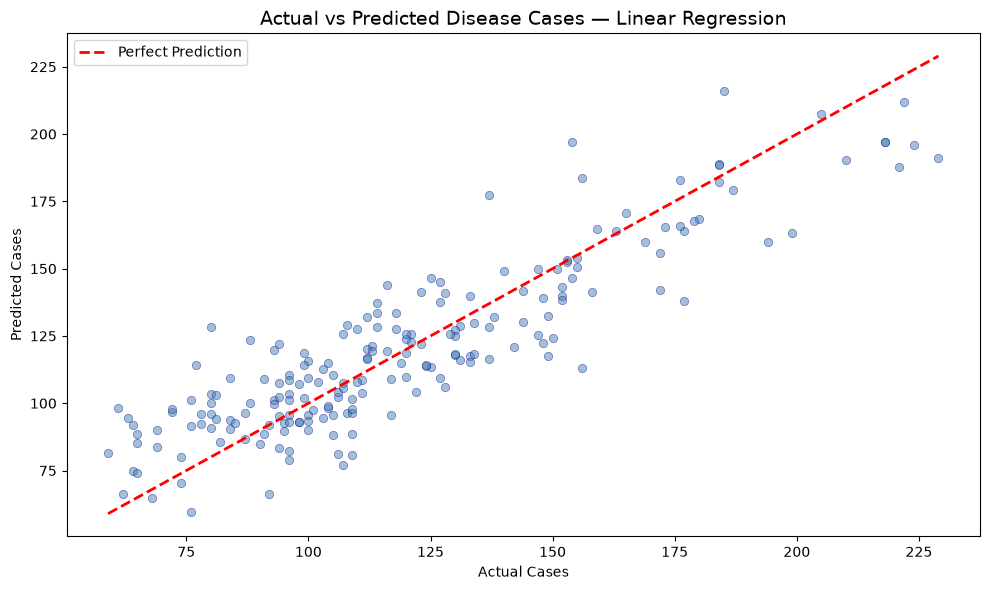

✅ Chart saved!


In [8]:
best_pred = rf_reg_pred if best_reg_name == 'Random Forest Regressor' else lr_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_pred, alpha=0.5, color='steelblue',
            edgecolors='darkblue', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')

plt.title(f'Actual vs Predicted Disease Cases — {best_reg_name}',
          fontsize=14)
plt.xlabel('Actual Cases')
plt.ylabel('Predicted Cases')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/actual_vs_predicted.png', dpi=150)
plt.show()
print('✅ Chart saved!')

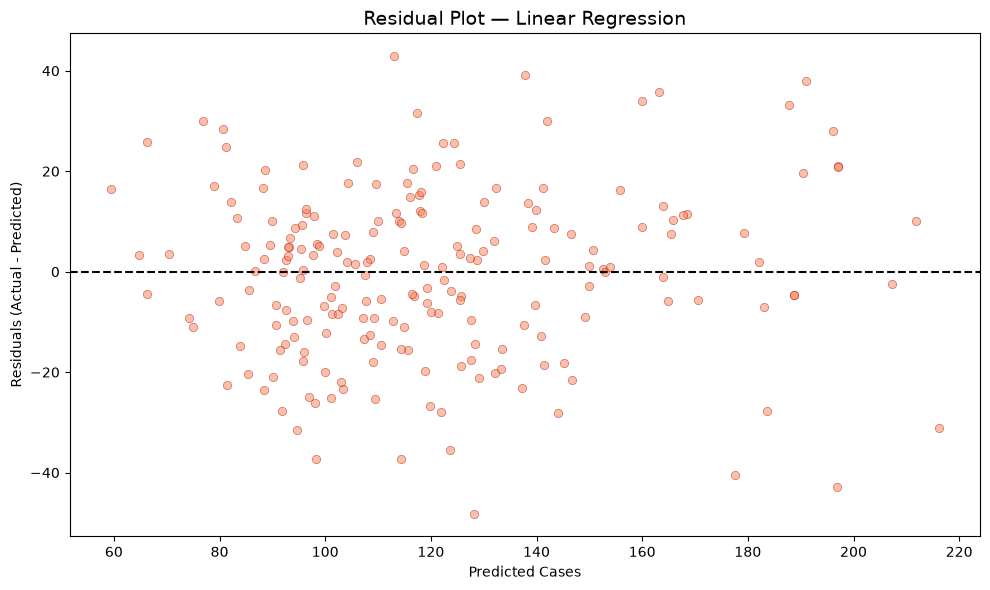

✅ Chart saved!

Residual stats:
Mean: -0.59
Std:  16.94


In [9]:
residuals = y_test - best_pred

plt.figure(figsize=(10, 6))
plt.scatter(best_pred, residuals, alpha=0.5, color='coral',
            edgecolors='darkred', linewidth=0.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.title(f'Residual Plot — {best_reg_name}', fontsize=14)
plt.xlabel('Predicted Cases')
plt.ylabel('Residuals (Actual - Predicted)')
plt.tight_layout()
plt.savefig('../reports/residual_plot.png', dpi=150)
plt.show()
print('✅ Chart saved!')
print(f'\nResidual stats:')
print(f'Mean: {residuals.mean():.2f}')
print(f'Std:  {residuals.std():.2f}')

In [10]:
if best_reg_name == 'Random Forest Regressor':
    reg_importances = pd.Series(
        rf_reg_model.feature_importances_,
        index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    reg_importances.plot(kind='barh', color='mediumseagreen')
    plt.title('Feature Importance — Regression Model', fontsize=14)
    plt.xlabel('Importance Score')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../reports/regression_feature_importance.png', dpi=150)
    plt.show()

    print('Top 5 Most Important Features:')
    print(reg_importances.head(5).round(3))
else:
    coefs = pd.Series(lr_model.coef_,
                      index=feature_cols).sort_values(ascending=False)
    print('Linear Regression Coefficients:')
    print(coefs.round(2))

Linear Regression Coefficients:
coliform_count_per100ml        24.44
turbidity_NTU                   9.12
rainfall_mm                     7.69
temperature_celsius             3.66
season_encoded                  1.13
month                           0.74
cases_2_months_ago              0.66
total_dissolved_solids_mg_L    -0.24
rainfall_last_month            -0.30
dissolved_oxygen_mg_L          -0.34
district_encoded               -0.74
pH                             -0.75
cases_last_month               -1.23
dtype: float64


In [11]:
import os
os.makedirs('../models', exist_ok=True)

best_reg_model = rf_reg_model if best_reg_name == 'Random Forest Regressor' else lr_model
joblib.dump(best_reg_model, '../models/regression_model.pkl')
joblib.dump(scaler, '../models/regression_scaler.pkl')

print(f'✅ Regression model saved: models/regression_model.pkl')
print(f'🏆 Model: {best_reg_name}')
print(f'🏆 R² Score: {reg_comparison["R2_Score"].max():.3f}')
print('\n🚀 Ready for Alert System tomorrow!')

✅ Regression model saved: models/regression_model.pkl
🏆 Model: Linear Regression
🏆 R² Score: 0.792

🚀 Ready for Alert System tomorrow!
